# Visual analytics of hotel bookings data

**Author:** Julià Minguillón (Python port)  
**Date:** April 2025

Python replication of `hotel_bookings.Rmd` using **plotnine** (a literal port of ggplot2).

**Library equivalences:**
- tidyverse / dplyr  → `pandas`
- ggplot2            → `plotnine` (same grammar of graphics)
- base hist/plot     → `matplotlib`
- ggmosaic           → `statsmodels.graphics.mosaicplot`
- fitdistrplus       → `scipy.stats` + Cullen & Frey custom
- ggstatsplot        → `plotnine` + `scipy.stats`
- lubridate          → `pandas.to_datetime`

## Load packages

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.graphics.mosaicplot import mosaic

from plotnine import (
    ggplot, aes, geom_histogram, geom_bar, geom_violin, geom_boxplot,
    geom_jitter, coord_flip, theme_light, theme, element_text,
    scale_color_manual, scale_fill_manual, labs,
)

warnings.filterwarnings("ignore")
%matplotlib inline

## Data loading and dimensions (N x M)

We read the dataset in CSV format, with 119,390 rows and 32 columns:

In [2]:
x = pd.read_csv("hotel_bookings.csv")
x.shape

(119390, 32)

## Data cleansing

Inspect with `describe()` (equivalent to R's `summary()`).

In [3]:
x.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


## Numerical variables

Some unexpected (outliers?) values can be observed:

1. A maximum of 55 in `adults`
2. A maximum of 10 in `children` (with NAs)
3. A maximum of 10 in `babies`
4. Negative or very high values in `adr`

Histogram of `adults` — base `hist()` equivalent in matplotlib:

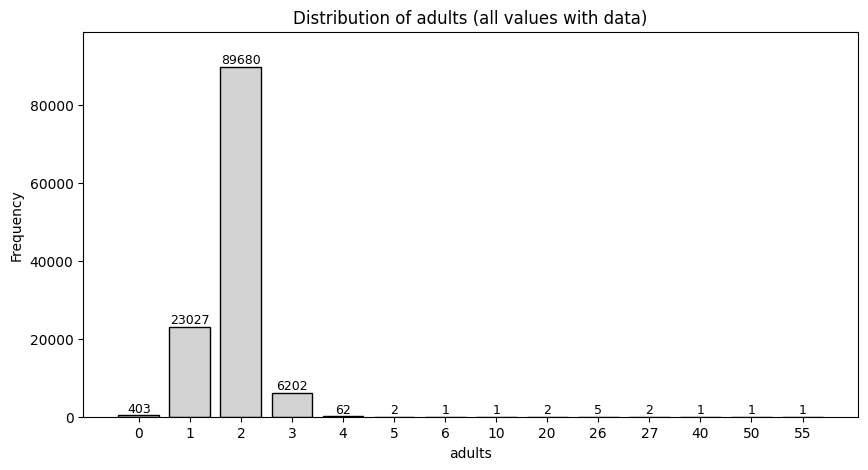

In [4]:
counts_adults = x["adults"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(counts_adults.index.astype(str), counts_adults.values,
               color="lightgray", edgecolor="black")
for bar, val in zip(bars, counts_adults.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             str(val), ha="center", va="bottom", fontsize=9)
plt.xlabel("adults"); plt.ylabel("Frequency")
plt.title("Distribution of adults (all values with data)")
plt.margins(y=0.1)
plt.show()

Sort and plot the values:

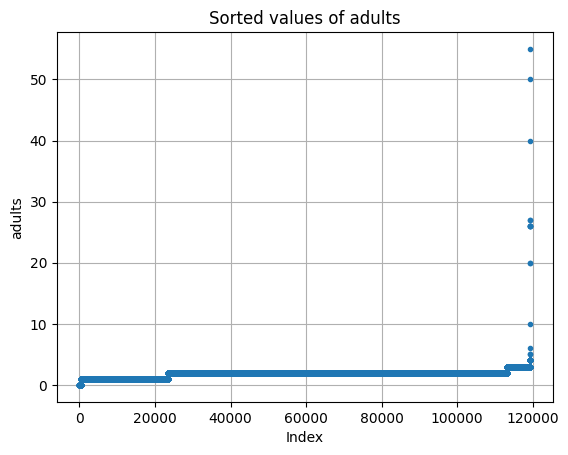

In [5]:
plt.figure()
plt.plot(np.sort(np.asarray(x["adults"])), marker=".", linestyle="none")
plt.grid(True)
plt.xlabel("Index"); plt.ylabel("adults")
plt.title("Sorted values of adults")
plt.show()

Use `value_counts()` (equivalent to R's `table()`):

In [6]:
x["adults"].value_counts().sort_index()

adults
0       403
1     23027
2     89680
3      6202
4        62
5         2
6         1
10        1
20        2
26        5
27        2
40        1
50        1
55        1
Name: count, dtype: int64

Remove rows with 10 or more adults:

In [7]:
x = x[x["adults"] < 10]
x.shape

(119377, 32)

**EXERCISE:** Repeat this process with `children` and `babies`.

Sorted plot of `adr`:

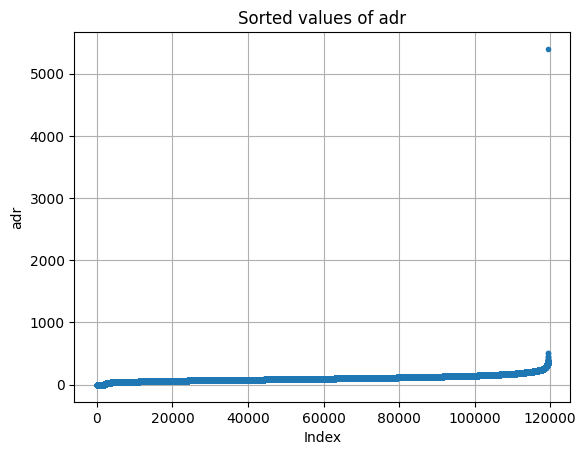

In [8]:
plt.figure()
plt.plot(np.sort(np.asarray(x["adr"])), marker=".", linestyle="none")
plt.grid(True)
plt.xlabel("Index"); plt.ylabel("adr")
plt.title("Sorted values of adr")
plt.show()

Remove the outlier and negative values, keep 0:

In [9]:
x = x[(x["adr"] >= 0) & (x["adr"] < 1000)]
x.shape

(119375, 32)

Histogram of `adr` using **plotnine** — same ggplot2 syntax as the Rmd:

```r
ggplot(data=x, aes(x=adr)) + 
  geom_histogram(bins=55, colour="black", fill = "lightgray") +
  theme_light()
```

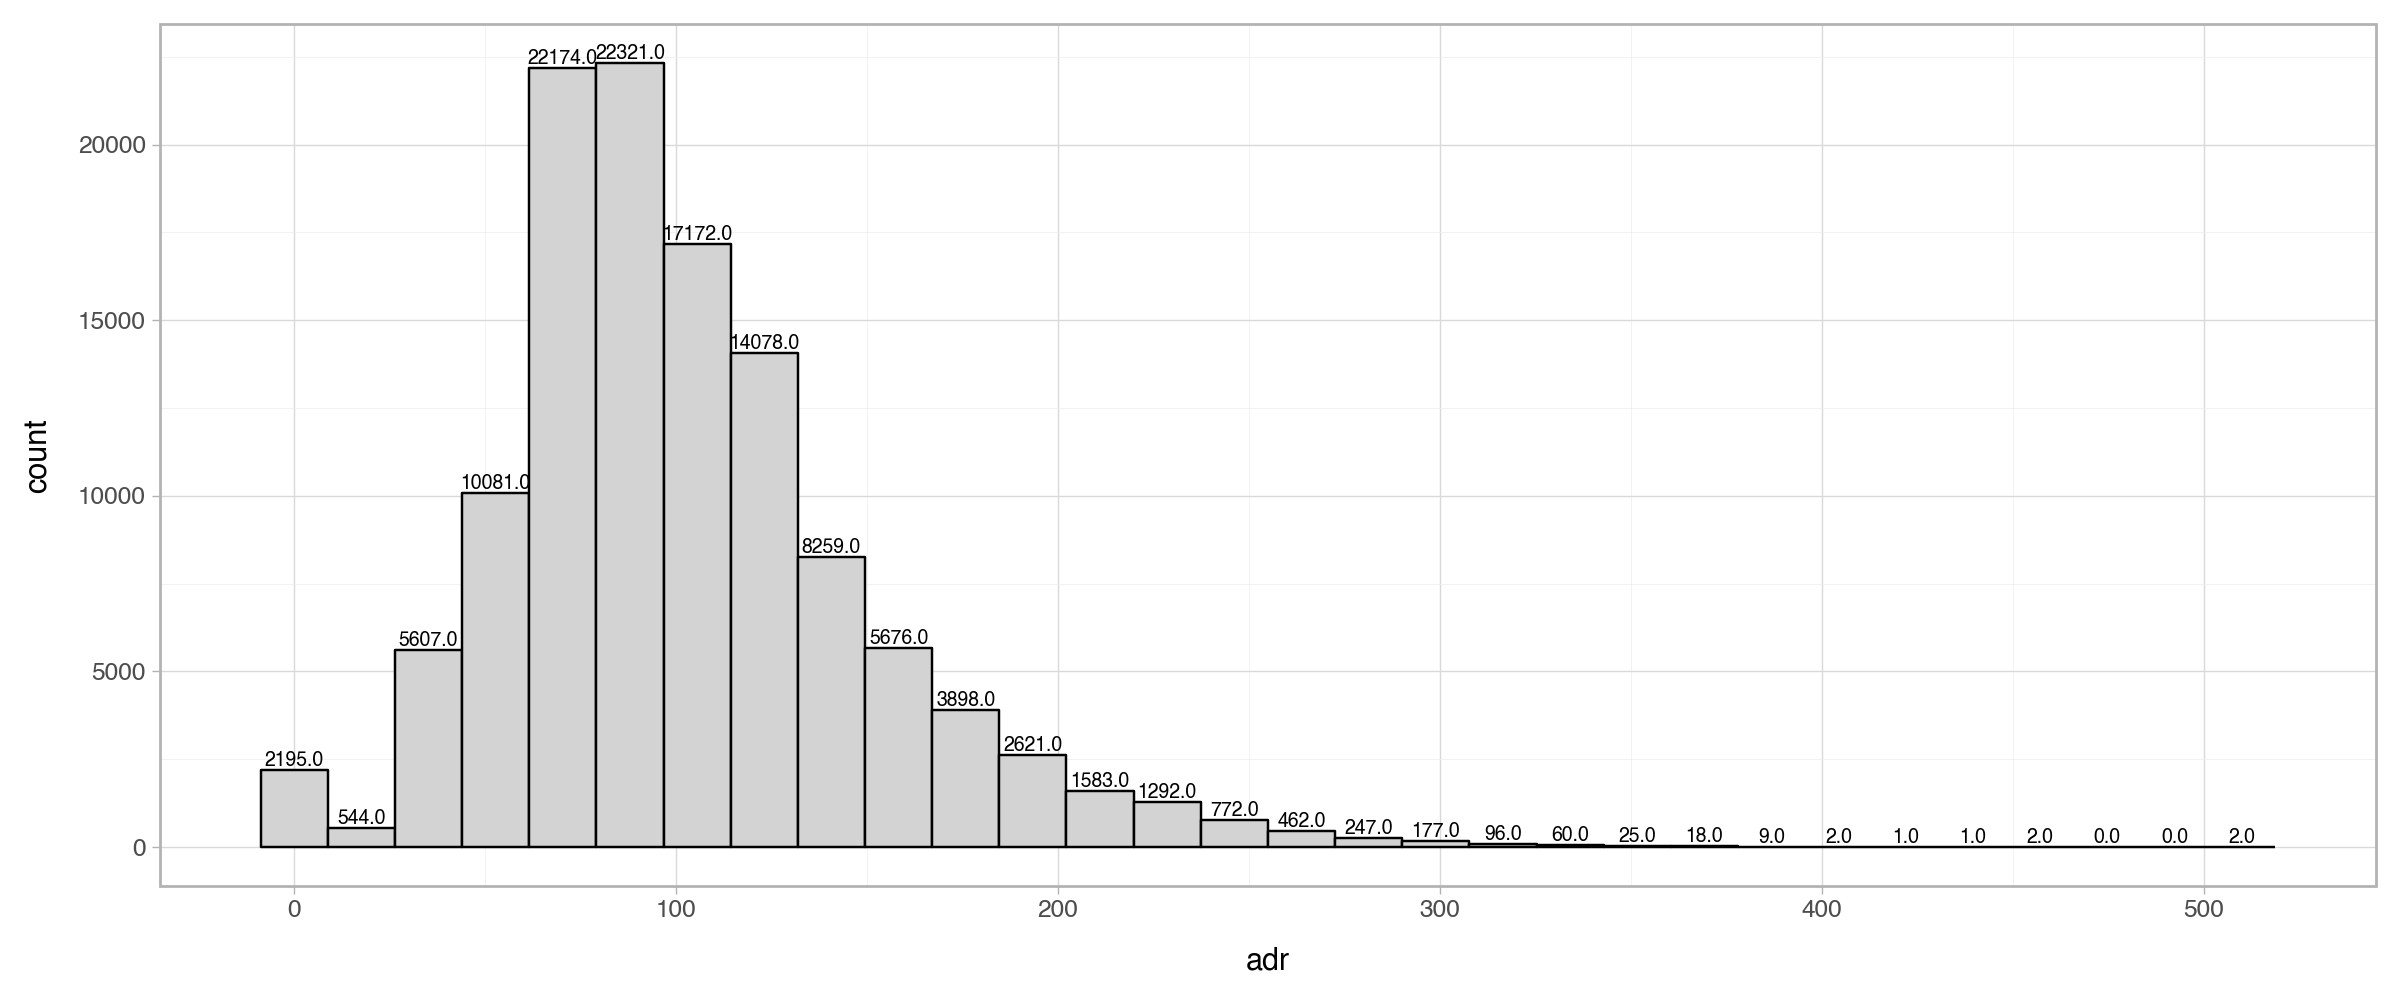

In [10]:
from plotnine import geom_text, after_stat

(
    ggplot(x, aes(x="adr"))
    + geom_histogram(bins=30, colour="black", fill="lightgray")
    + geom_text(aes(label=after_stat("count")),
                stat="bin", bins=30, va="bottom", size=7)
    + theme_light()
    + theme(figure_size=(12, 5))
)

`fitdistrplus::descdist()` approximation (Cullen & Frey graph):

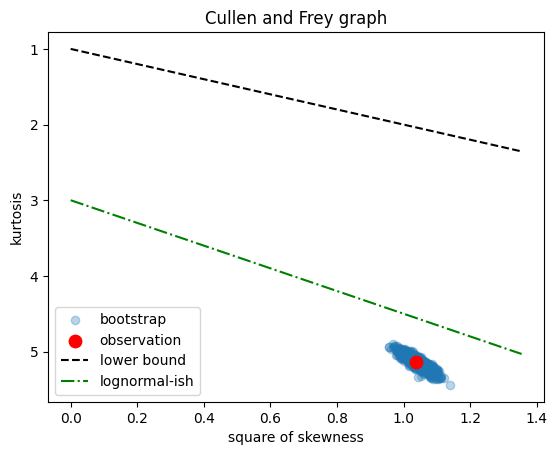

{'skewness': np.float64(1.018843812799225),
 'kurtosis': np.float64(5.133030569713419)}

In [11]:
def descdist(data, boot=1000, seed=0):
    """Approximate fitdistrplus::descdist - Cullen & Frey graph."""
    data = np.asarray(data, dtype=float)
    rng = np.random.default_rng(seed)
    obs_skew = stats.skew(data)
    obs_kurt = stats.kurtosis(data, fisher=False)
    boot_skew = np.empty(boot); boot_kurt = np.empty(boot)
    n = len(data)
    for i in range(boot):
        s = rng.choice(data, size=n, replace=True)
        boot_skew[i] = stats.skew(s)
        boot_kurt[i] = stats.kurtosis(s, fisher=False)
    plt.figure()
    plt.scatter(boot_skew**2, boot_kurt, alpha=0.3, label="bootstrap")
    plt.scatter([obs_skew**2], [obs_kurt], color="red", s=80,
                label="observation", zorder=5)
    s2 = np.linspace(0, max(boot_skew**2) * 1.1 + 0.1, 200)
    plt.plot(s2, s2 + 1, "k--", label="lower bound")
    plt.plot(s2, 1.5 * s2 + 3, "g-.", label="lognormal-ish")
    plt.gca().invert_yaxis()
    plt.xlabel("square of skewness"); plt.ylabel("kurtosis")
    plt.title("Cullen and Frey graph"); plt.legend()
    plt.show()
    return {"skewness": obs_skew, "kurtosis": obs_kurt}

descdist(x["adr"].values, boot=1000)

Final cleansing:

1. remove 0-day stays
2. remove 0-cost stays
3. remove stays with no guests
4. replace NAs in `children` with 0

In [12]:
x["children"] = x["children"].fillna(0)
x = x[
    (x["adr"] > 0)
    & ((x["stays_in_week_nights"] + x["stays_in_weekend_nights"]) > 0)
    & ((x["adults"] + x["children"] + x["babies"]) > 0)
    & x["children"].notna()
]
x.shape

(117398, 32)

## Categorical variables

Histogram of `adr` split by hotel type — **plotnine**:

```r
ggplot(data=x, aes(x=adr, fill=hotel)) + 
  geom_histogram(bins=50, colour="black") +
  theme_light()
```

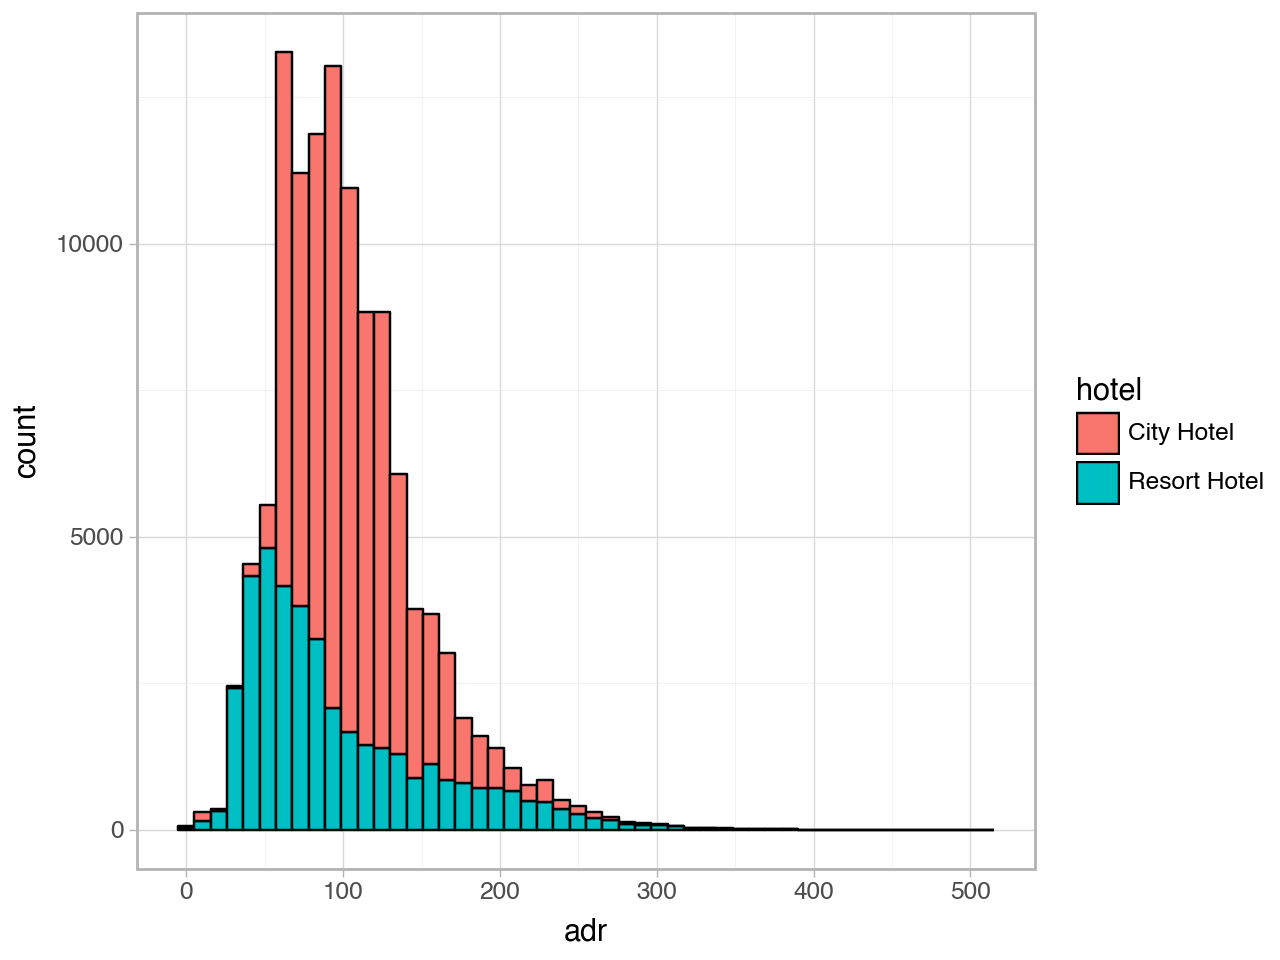

In [13]:
(
    ggplot(x, aes(x="adr", fill="hotel"))
    + geom_histogram(bins=50, colour="black")
    + theme_light()
)

Violin + boxplot of `adr` by hotel — **plotnine**:

```r
ggplot(data=x, aes(x=hotel, y=adr, fill=hotel)) + 
  geom_violin() + geom_boxplot(width=.1, outliers = F) +
  coord_flip() + theme_light()
```

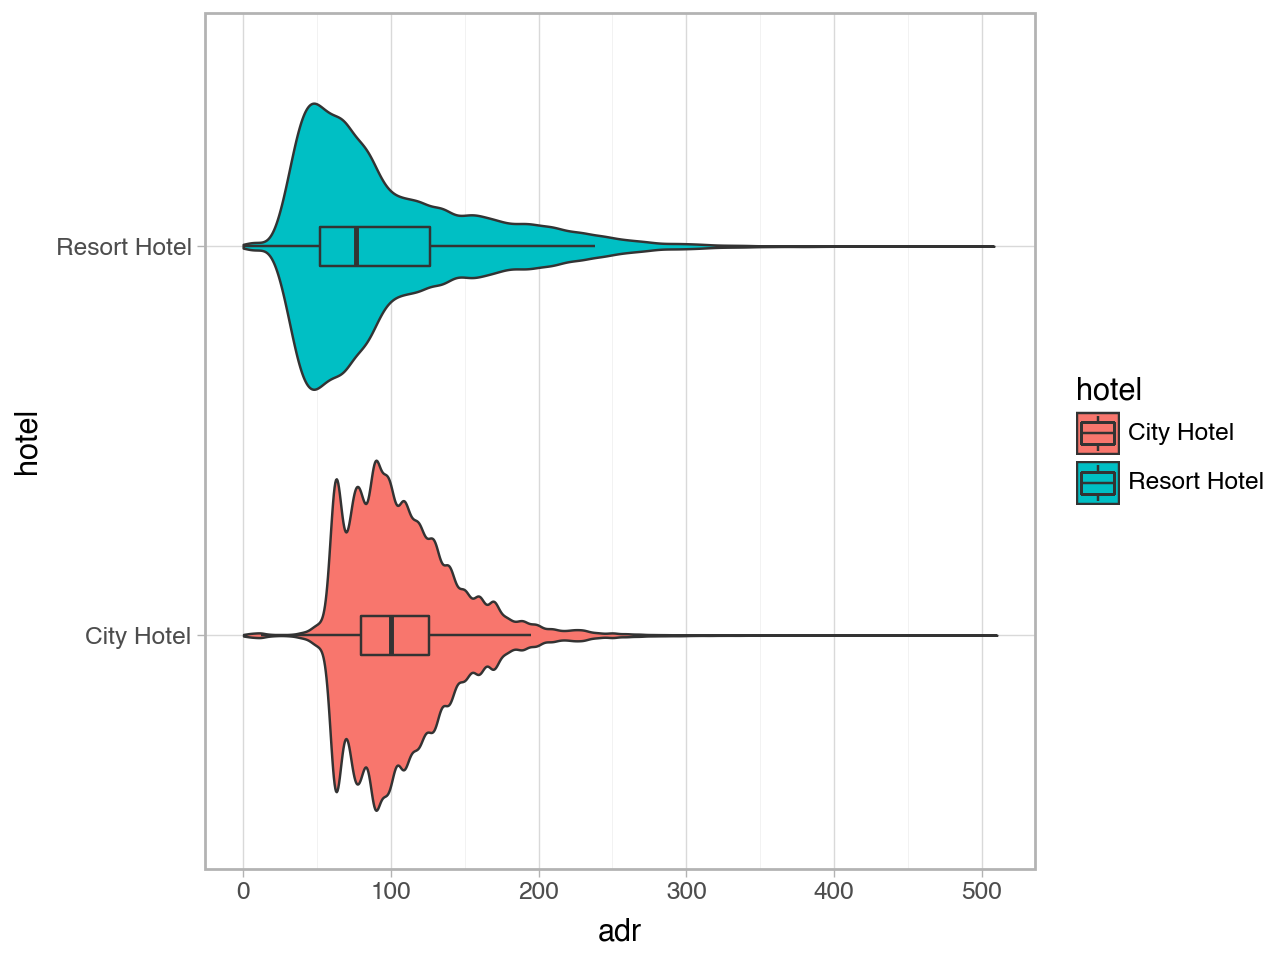

In [14]:
(
    ggplot(x, aes(x="hotel", y="adr", fill="hotel"))
    + geom_violin()
    + geom_boxplot(width=0.1, outlier_shape="")
    + coord_flip()
    + theme_light()
)

`ggstatsplot::ggbetweenstats` equivalent — boxplot + jitter + Mann-Whitney p-value annotated:

Mann-Whitney U adr ~ hotel: U=1943494626, p=0.000e+00


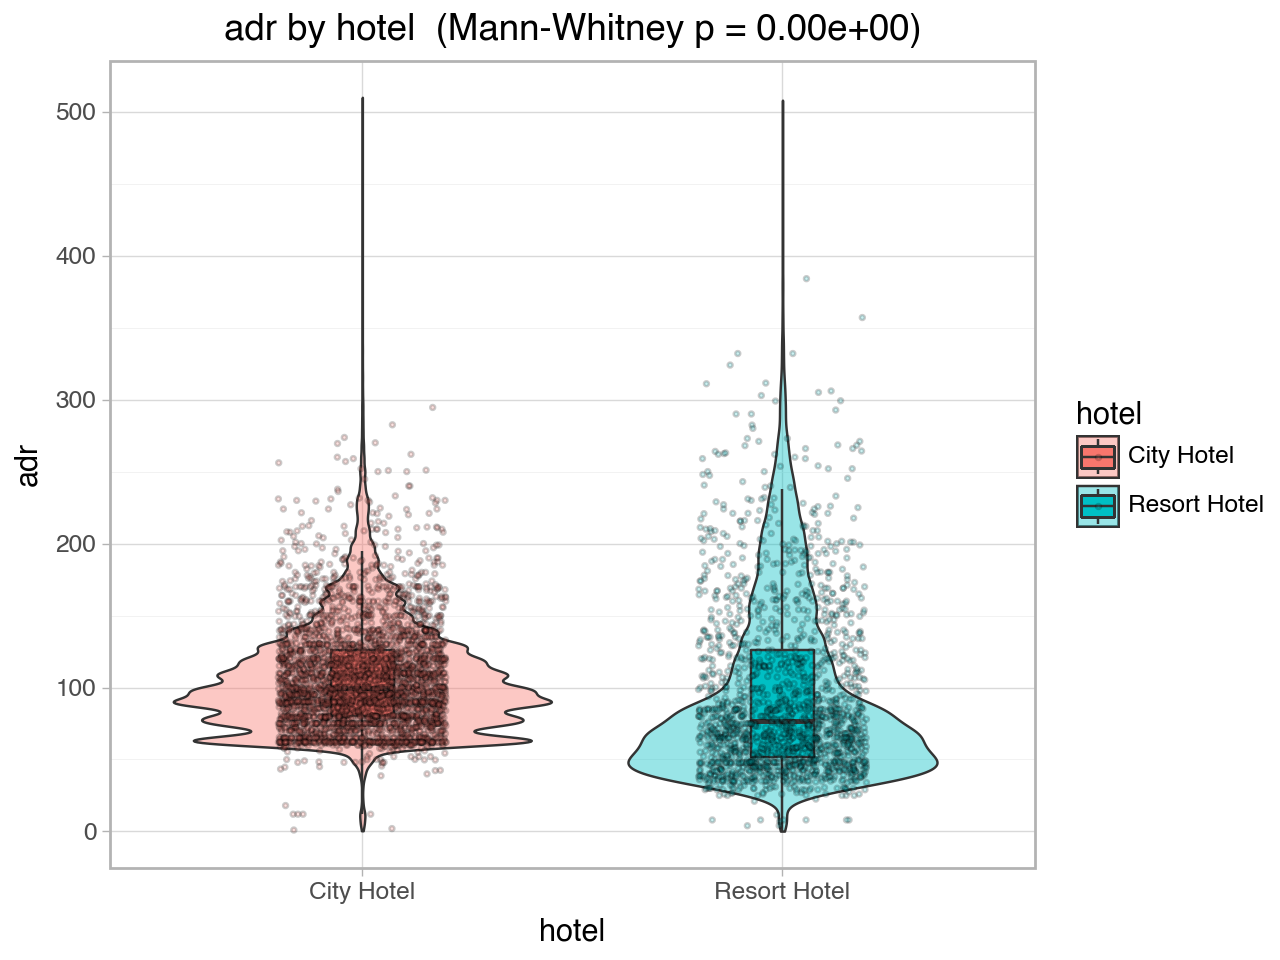

In [15]:
city   = x.loc[x["hotel"] == "City Hotel",   "adr"].values
resort = x.loc[x["hotel"] == "Resort Hotel", "adr"].values
u_stat, p_val = stats.mannwhitneyu(city, resort, alternative="two-sided")
print(f"Mann-Whitney U adr ~ hotel: U={u_stat:.0f}, p={p_val:.3e}")

sample = x.sample(min(len(x), 5000), random_state=0)
(
    ggplot(x, aes(x="hotel", y="adr", fill="hotel"))
    + geom_violin(alpha=0.4)
    + geom_boxplot(width=0.15, outlier_shape="")
    + geom_jitter(data=sample, alpha=0.2, size=0.5, width=0.2)
    + labs(title=f"adr by hotel  (Mann-Whitney p = {p_val:.2e})")
    + theme_light()
)

Countries with at least 100 bookings, ordered by frequency, filled by hotel — **plotnine**:

```r
xx = x %>% group_by(country) %>% mutate(pais=n()) %>% filter(pais>=100)
ggplot(data=xx, aes(x=reorder(country, -pais))) + 
  geom_bar(stat="count", aes(fill=hotel)) +
  theme_light() + 
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))
```

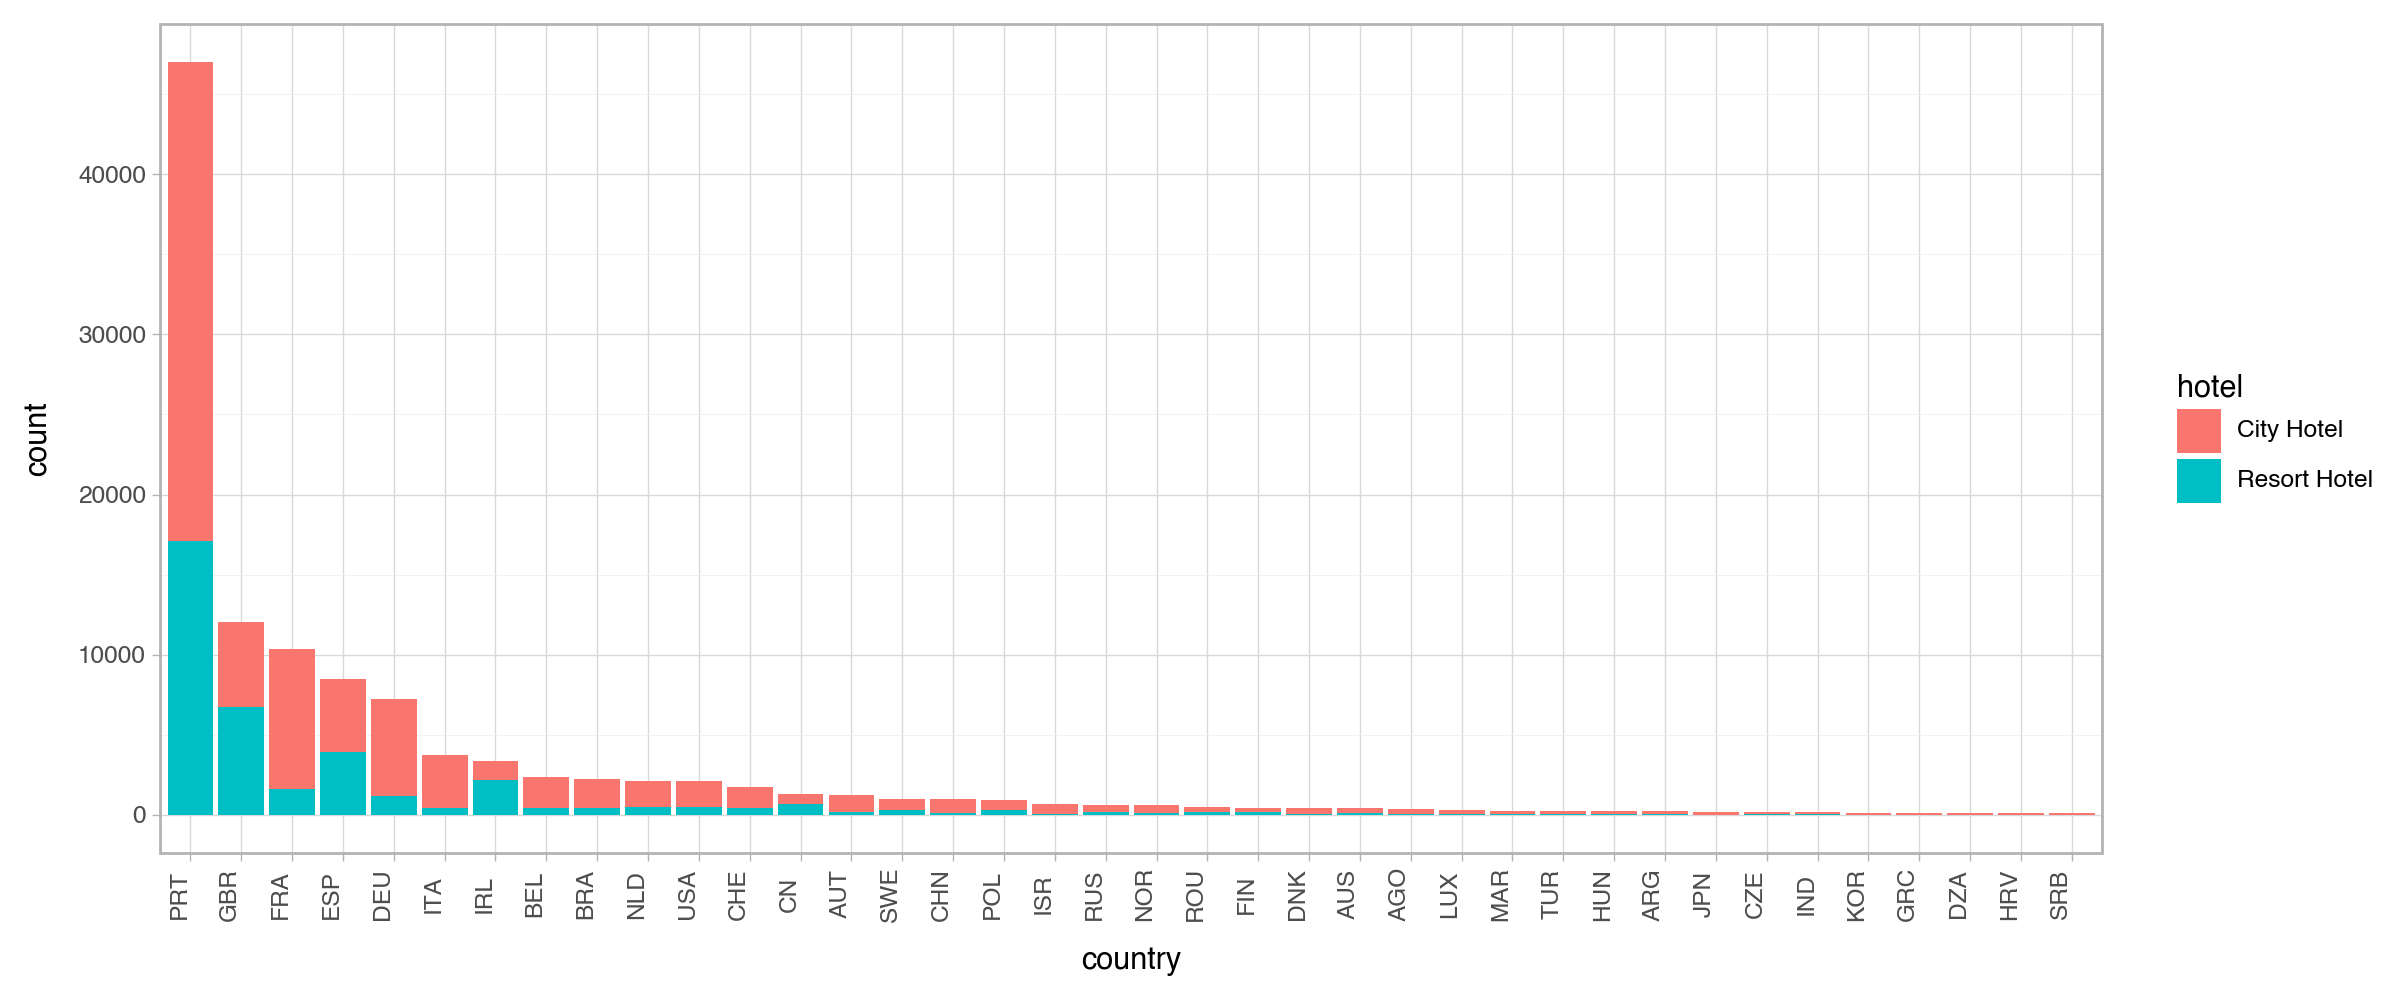

In [16]:
counts = x.groupby("country").size()
xx = x[x["country"].isin(counts[counts >= 100].index)].copy()
order = (xx.groupby("country").size()
           .sort_values(ascending=False).index.tolist())
xx["country"] = pd.Categorical(xx["country"], categories=order, ordered=True)

(
    ggplot(xx, aes(x="country", fill="hotel"))
    + geom_bar(stat="count")
    + theme_light()
    + theme(
        axis_text_x=element_text(angle=90, vjust=0.5, hjust=1),
        figure_size=(12, 5),
    )
)

**EXERCISE:** Are there differences between residents of Portugal and the rest?

Mosaic plot — `hotel` vs `is_canceled` (plotnine has no `geom_mosaic`, fall back to `statsmodels`):

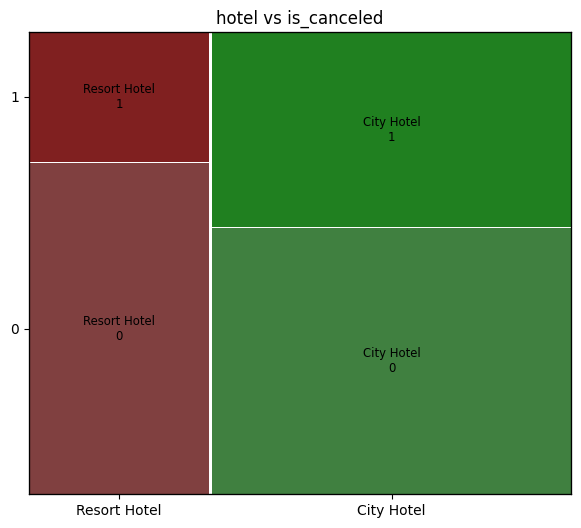

In [17]:
x["is_canceled"] = x["is_canceled"].astype("category")

fig, _ = plt.subplots(figsize=(7, 6))
mosaic(x, ["hotel", "is_canceled"], title="hotel vs is_canceled", ax=fig.gca())
plt.show()

Mosaic plot — countries (>=1000 bookings) vs `is_canceled`:

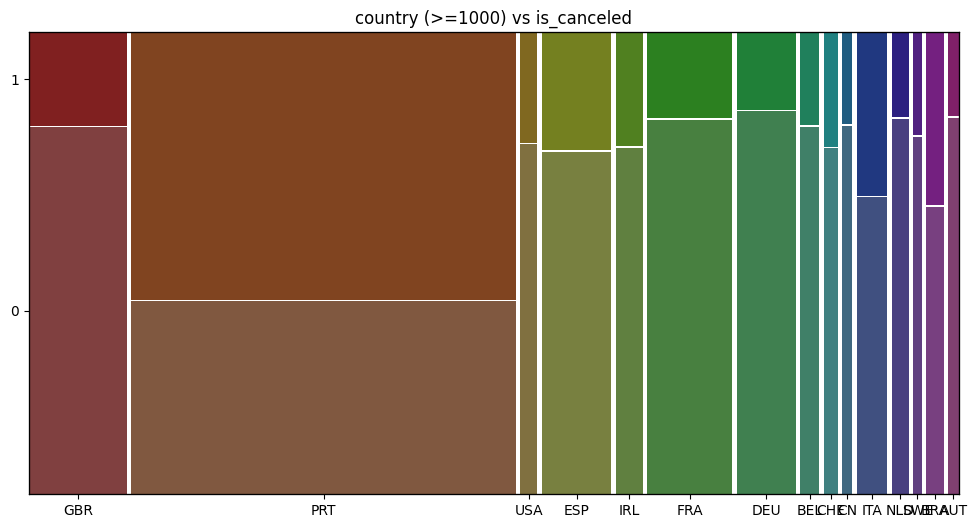

In [18]:
counts2 = x.groupby("country").size()
xx2 = x[x["country"].isin(counts2[counts2 >= 1000].index)].copy()

fig, _ = plt.subplots(figsize=(12, 6))
mosaic(xx2, ["country", "is_canceled"],
       title="country (>=1000) vs is_canceled",
       labelizer=lambda _: "", ax=fig.gca())
plt.show()

## Arrival date analysis

Bookings per day — **plotnine**:

```r
x$dia=as_date(paste0(x$arrival_date_year,'-',x$arrival_date_month,'-',x$arrival_date_day_of_month))
ggplot(data=x,aes(x=dia,group=arrival_date_year,color=as.factor(arrival_date_year))) + 
  geom_bar() + scale_color_manual(values=c("2015"="red","2016"="green","2017"="blue")) + 
  theme_light() + theme(legend.position='none')
```

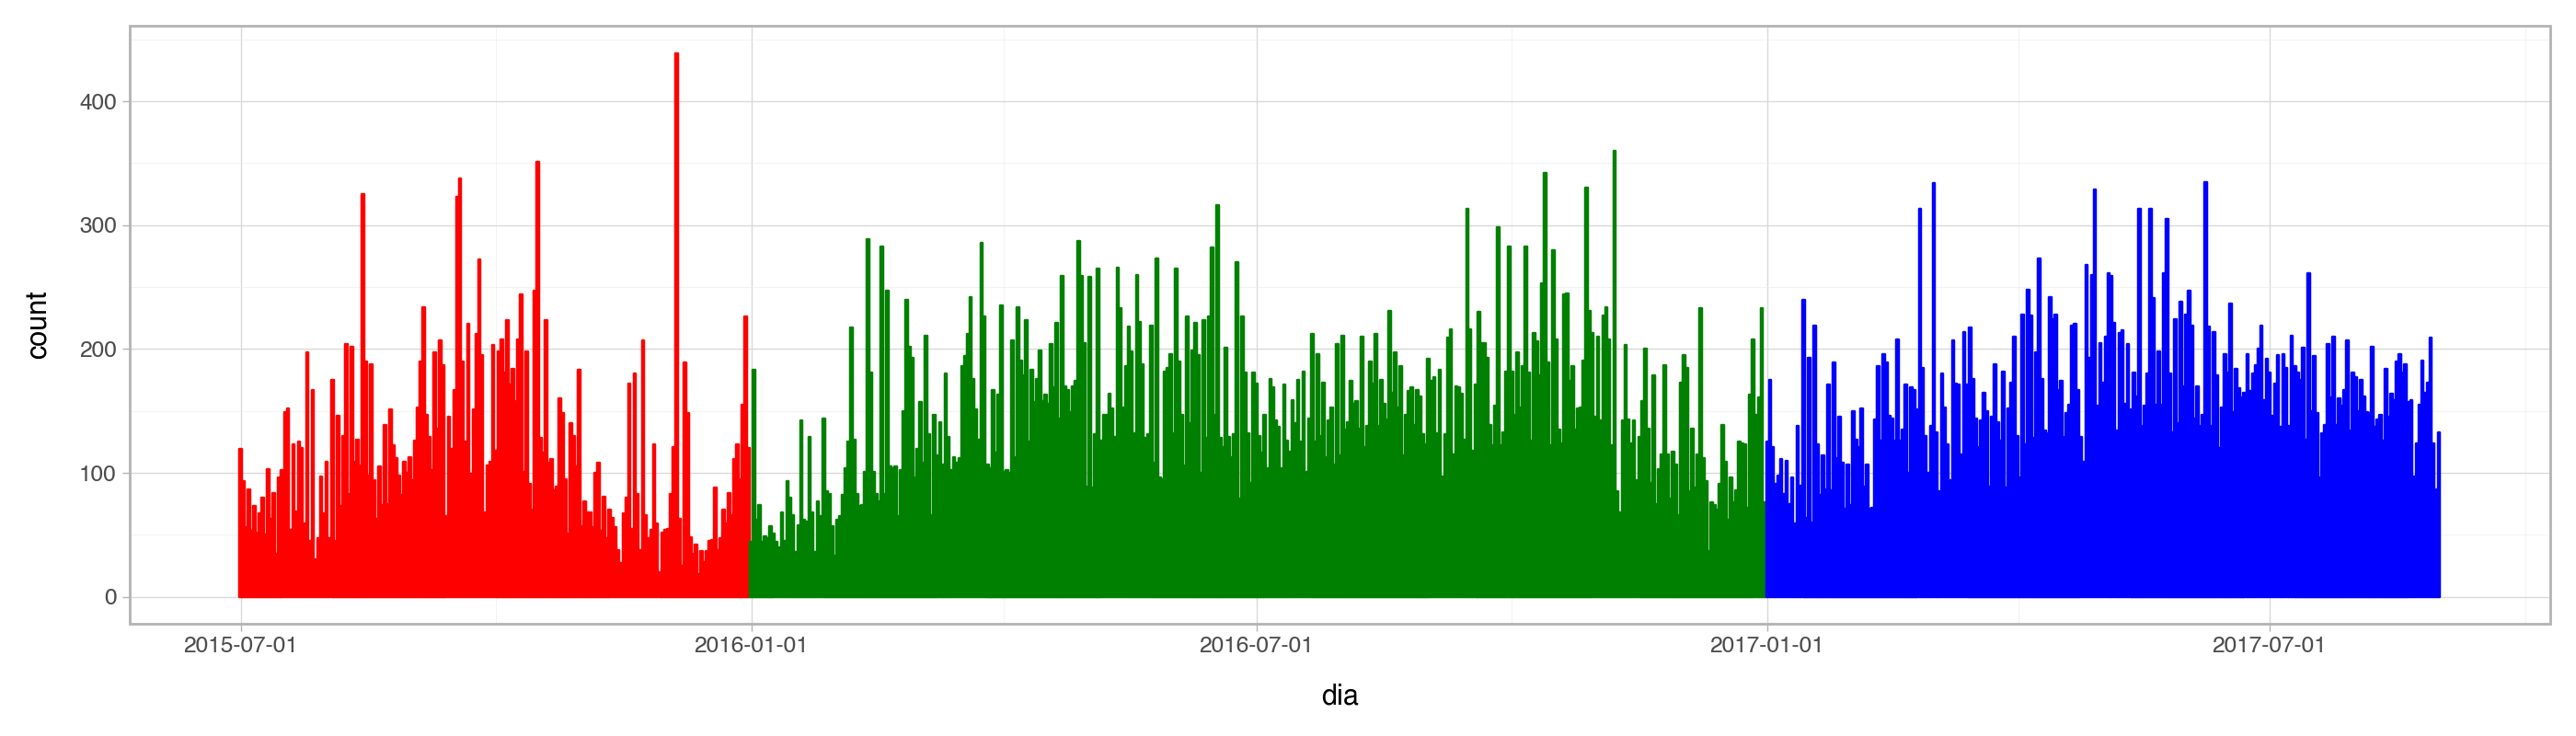

In [19]:
x["dia"] = pd.to_datetime(
    x["arrival_date_year"].astype(str) + "-"
    + x["arrival_date_month"].astype(str) + "-"
    + x["arrival_date_day_of_month"].astype(str),
    format="%Y-%B-%d",
)
x["year_factor"] = x["arrival_date_year"].astype(str)

(
    ggplot(x, aes(x="dia", fill="year_factor", color="year_factor"))
    + geom_bar()
    + scale_color_manual(values={"2015": "red", "2016": "green", "2017": "blue"})
    + scale_fill_manual(values={"2015": "red", "2016": "green", "2017": "blue"})
    + theme_light()
    + theme(legend_position="none", figure_size=(14, 4))
)

In [20]:
day_counts = x["dia"].value_counts()
print("max(table(x$dia)):", day_counts.max())
print("which.max(table(x$dia)):", day_counts.idxmax().date())

max(table(x$dia)): 439
which.max(table(x$dia)): 2015-12-05


## Trip-type categorization

1. `stays_in_weekend_nights` == 0 → **work**
2. `stays_in_week_nights` == 0, or == 1 and check-in on Friday → **weekend**
3. `stays_in_week_nights` == 5 and `stays_in_weekend_nights` ∈ {3, 4} → **package**
4. `stays_in_week_nights` ≤ 5 and `stays_in_weekend_nights` < 3 → **work+rest**
5. otherwise → **rest**

Note: pandas `weekday`, Monday=0..Sunday=6, so Friday=4.

In [21]:
wday = x["dia"].dt.weekday
wkn = x["stays_in_weekend_nights"]
wn  = x["stays_in_week_nights"]

conditions = [
    wkn == 0,
    wn == 0,
    (wn == 1) & (wday == 4),
    (wn == 5) & ((wkn == 3) | (wkn == 4)),
    (wn <= 5) & (wkn < 3),
]
choices = ["work", "weekend", "weekend", "package", "work+rest"]
x["tipo"] = np.select(conditions, choices, default="rest")

x["tipo"].value_counts()

tipo
work+rest    54905
work         50492
weekend       6806
rest          4797
package        398
Name: count, dtype: int64

**EXERCISE:** Explore the enriched dataset and decide what story to tell:

1. do tourists from different countries travel in different dates?
2. differences in cancellations among groups
3. relationship between type of stay `tipo` and cost `adr`
4. differences among groups with respect to hotel type

In [22]:
x.to_csv("hotel_bookings_clean.csv", index=False)
print("Cleaned data saved -> hotel_bookings_clean.csv  shape:", x.shape)

Cleaned data saved -> hotel_bookings_clean.csv  shape: (117398, 35)
